## Killer Sudoku

In [1]:
import pulp as plp

## What is Killer Sudoku?

In addition to the standard Sudoku rules, Killer Sudoku adds "cage"-sum constraints.

In [2]:
import pulp as plp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import timeit

### Standard Constraints

Constraint 1: Each cell should be filled with a single value between 1 and 9<br>
Constraint 2: Each row should contain every number from 1 to 9 once<br>
Constraint 3: Each column should contain every number from 1 to 9 once<br>
Constraint 4: Each 3x3 grid, starting from top left, should contain every number from 1 to 9 once

In [3]:
def add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values):
    
    # Constraint to ensure only one value is filled for a cell
    for row in rows:
        for col in cols:
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value] for value in values]),
                                        sense=plp.LpConstraintEQ, rhs=1, name=f"constraint_sum_{row}_{col}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in a row        
    for row in rows:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for col in cols]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_row_{row}_{value}"))

    # Constraint to ensure that values from 1 to 9 is filled only once in a column        
    for col in cols:
        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for row in rows]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_col_{col}_{value}"))


    # Constraint to ensure that values from 1 to 9 is filled only once in the 3x3 grid       
    for grid in grids:
        grid_row  = int(grid/3)
        grid_col  = int(grid%3)

        for value in values:
            prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[grid_row*3+row][grid_col*3+col][value]*value  for col in range(0,3) for row in range(0,3)]),
                                        sense=plp.LpConstraintEQ, rhs=value, name=f"constraint_uniq_grid_{grid}_{value}"))

### Killer Constraints

Constraint 5: Digits in each cage sum to the target <br>
Constraint 6: No digit repeats within a cage

In [4]:
def add_killer_cage_constraints(prob, grid_vars, cages, values):

    for cage_id, (target, cells) in enumerate(cages):

        # Constraint 5: digits in the cage sum to the target
        prob.addConstraint(plp.LpConstraint(
            e=plp.lpSum([grid_vars[row][col][value] * value for (row, col) in cells for value in values]),
            sense=plp.LpConstraintEQ,
            rhs=target,
            name=f"constraint_cage_sum_{cage_id}"))

        # Constraint 6: no digit repeats within the cage
        for value in values:
            prob.addConstraint(plp.LpConstraint(
                e=plp.lpSum([grid_vars[row][col][value] for (row, col) in cells]),
                sense=plp.LpConstraintLE,
                rhs=1,
                name=f"constraint_cage_uniq_{cage_id}_{value}"))

### Add the prefilled values as constraints

Constraint 7: Fill the prefilled cells as constraints to the LP problem. (Killer Sudoku problems generally do not have prefilled values, so this constraint exists only if it's an easier version with prefilled values.)

In [5]:
def add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values):
    for row in rows:
        for col in cols:
            if(input_sudoku[row][col] != 0):
                prob.addConstraint(plp.LpConstraint(e=plp.lpSum([grid_vars[row][col][value]*value  for value in values]), 
                                                    sense=plp.LpConstraintEQ, 
                                                    rhs=input_sudoku[row][col],
                                                    name=f"constraint_prefilled_{row}_{col}"))

## Solutions

### Extract solution from the target variable to a list array

In [6]:
def extract_solution(grid_vars, rows, cols, values):
    solution = [[0 for col in cols] for row in rows]
    for row in rows:
        for col in cols:
            for value in values:
                if plp.value(grid_vars[row][col][value]):
                    solution[row][col] = value 
    return solution

### Print the solution as a Sudoku grid

In [7]:
def print_solution(solution, rows, cols):
    # Print the final result
    print(f"\nFinal result:")

    print("\n\n+ ----------- + ----------- + ----------- +",end="")
    for row in rows:
        print("\n",end="\n|  ")
        for col in cols:
            num_end = "  |  " if ((col+1)%3 == 0) else "   "
            print(solution[row][col],end=num_end)

        if ((row+1)%3 == 0):
            print("\n\n+ ----------- + ----------- + ----------- +",end="")

## Killer Sudoku Solver

Killer Sudoku Solver: Find a solution where all constraints are satisfied.
Need to identify a feasible solution and not an optimal solution.

Decision Variables: 9x9x9 binary variables: (row, column, value)
For every cell, only one of the 9 binary variables for that (row, col) can be set (constraint).

In [8]:
def solve_killer_sudoku(cages, input_sudoku=None):
    # Create the linear programming problem
    prob = plp.LpProblem("Killer_Sudoku_Solver")

    rows = range(0, 9)
    cols = range(0, 9)
    grids = range(0, 9)
    values = range(1, 10)

    # Decision Variable/Target variable
    grid_vars = plp.LpVariable.dicts("grid_value", (rows, cols, values), cat='Binary')

    # Set the objective function
    # Set a dummy objective
    objective = plp.lpSum(0)
    prob.setObjective(objective)

    # Create the default Sudoku constraints
    add_default_sudoku_constraints(prob, grid_vars, rows, cols, grids, values)

    # Add the Killer Sudoku cage constraints
    add_killer_cage_constraints(prob, grid_vars, cages, values)

    # Fill any prefilled values as constraints (if provided)
    if input_sudoku is not None:
        add_prefilled_constraints(prob, input_sudoku, grid_vars, rows, cols, values)

    # Solve the problem
    prob.solve(plp.PULP_CBC_CMD(msg=0))
    print(f"Solver runtime: {prob.solutionTime:.3f} seconds")

    # Print the status of the solution
    solution_status = plp.LpStatus[prob.status]
    print(f'Solution Status = {plp.LpStatus[prob.status]}')

    # Extract the solution if an optimal solution has been identified
    if solution_status == 'Optimal':
        solution = extract_solution(grid_vars, rows, cols, values)
        print_solution(solution, rows, cols)
        return solution

    return None

In [9]:
def get_runtime(cages, repeat):
    times = timeit.repeat(
        lambda: solve_killer_sudoku(cages=cages),
        repeat=repeat, number=1
    )
    
    return times

In [10]:
#################################################################################
# plot_avg_runtime() is developed with the assistance of Claude (Anthropic, 2026)
#################################################################################

def plot_avg_runtime(examples, repeat):
    avgs = []
    for label, cages in examples:
        times = get_runtime(cages, repeat)
        avgs.append(sum(times) / len(times))

    labels = [e[0] for e in examples]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, avgs, width=0.5, zorder=3)
    ax.set_ylabel("Average Runtime (s)")
    ax.set_title(f"Avg. Runtime ({repeat} runs)")
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.set_ylim(0, max(avgs) * 1.3)
    for bar, val in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(avgs) * 0.02,
                f"{val:.3f}s", ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.savefig("killer_sudoku_examples/runtime.jpg", dpi=150, bbox_inches='tight')
    plt.show()

## Define the Puzzle

Each cage is defined as `(target_sum, [(row, col), ...])`. This is a classic Killer Sudoku puzzle. Since all information comes from the cages, there is generally no prefilled grid.

In [11]:
def draw_killer_sudoku(cages, solution=None, title="Killer Sudoku"):
    cage_grid = np.full((9, 9), -1, dtype=int)
    for cage_id, (target, cells) in enumerate(cages):
        for (r, c) in cells:
            cage_grid[r, c] = cage_id

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)

    colors = plt.cm.Pastel1(np.linspace(0, 1, len(cages)))

    for r in range(9):
        for c in range(9):
            cid = cage_grid[r, c]
            color = colors[cid % len(colors)] if cid >= 0 else 'white'
            rect = patches.Rectangle((c, 8 - r), 1, 1,
                                      linewidth=0.3, edgecolor='gray', facecolor=color)
            ax.add_patch(rect)

    for cage_id, (target, cells) in enumerate(cages):
        top_left = min(cells, key=lambda rc: (rc[0], rc[1]))
        r, c = top_left
        ax.text(c + 0.08, 8 - r + 0.88, str(target),
                fontsize=6.5, fontweight='bold', color='black', va='top', ha='left')

    for r in range(9):
        for c in range(9):
            cid = cage_grid[r, c]
            if c + 1 < 9 and cage_grid[r, c + 1] != cid:
                ax.plot([c+1, c+1], [8-r, 9-r], 'k--', linewidth=0.8)
            if r + 1 < 9 and cage_grid[r + 1, c] != cid:
                ax.plot([c, c+1], [8-r, 8-r], 'k--', linewidth=0.8)

    for i in range(0, 10, 3):
        ax.plot([i, i], [0, 9], 'k-', linewidth=3)
        ax.plot([0, 9], [i, i], 'k-', linewidth=3)

    if solution is not None:
        for r in range(9):
            for c in range(9):
                ax.text(c + 0.5, 8 - r + 0.5, str(solution[r][c]),
                        fontsize=13, ha='center', va='center', color='#1a1a1a')

    plt.tight_layout()
    plt.show()

### Example 1

In [12]:
cages1 = [
    (3,  [(0,0),(0,1)]),
    (15, [(0,2),(0,3),(0,4)]),
    (22, [(0,5),(1,5),(1,4),(2,4)]),
    (4,  [(0,6),(1,6)]),
    (16, [(0,7),(1,7)]),
    (15, [(0,8),(1,8),(2,8),(3,8)]),
    (25, [(1,0),(2,0),(1,1), (2,1)]),
    (17, [(1,2),(1,3)]),
    (9,  [(2,2),(2,3), (3,3)]),
    (8,  [(2,5),(3,5), (4,5)]),
    (20, [(2,6),(2,7),(3,6)]),
    (6, [(3,0),(4,0)]),
    (14, [(3,1),(3,2)]),
    (17,  [(3,4),(4,4),(5,4)]),
    (17,  [(3,7),(4,7),(4,6)]),
    (13, [(4,1),(5,1),(4,2)]),
    (20, [(4,3),(5,3),(6,3)]),
    (12, [(4,8),(5,8)]),
    (27, [(5,0),(6,0),(7,0),(8,0)]),
    (6, [(5,2),(6,2),(6,1)]),
    (20,  [(5,5),(6,5),(6,6)]),
    (6, [(5,6),(5,7)]),
    (8, [(7,1),(8,1)]),
    (16, [(7,2),(8,2)]),
    (10,  [(6,4),(7,4),(7,3),(8,3)]),
    (13, [(8,4),(8,5),(8,6)]),
    (15,  [(7,5),(7,6)]),
    (14,  [(7,8),(7,7),(6,8),(6,7)]),
    (17, [(8,7),(8,8)]),
]

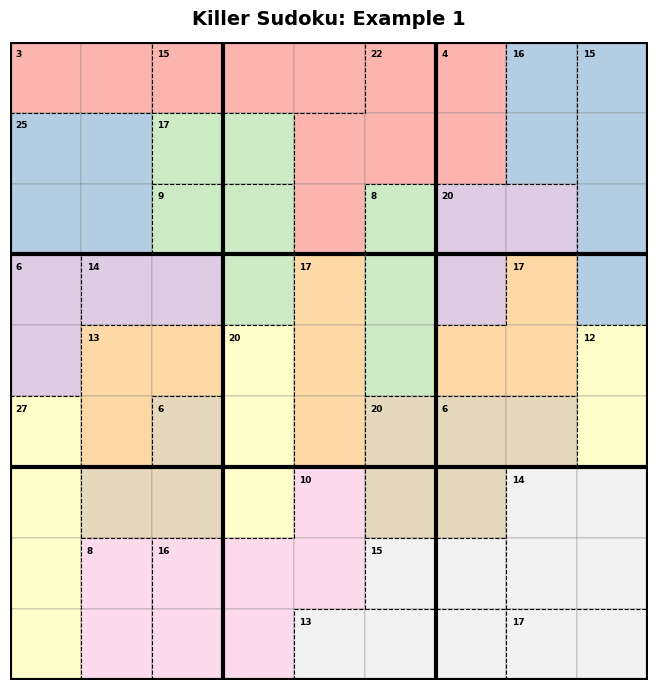

In [13]:
draw_killer_sudoku(cages1, title="Killer Sudoku: Example 1")

In [14]:
solution1 = solve_killer_sudoku(cages1)

Solver runtime: 0.582 seconds
Solution Status = Optimal

Final result:


+ ----------- + ----------- + ----------- +

|  2   1   5  |  6   4   7  |  3   9   8  |  

|  3   6   8  |  9   5   2  |  1   7   4  |  

|  7   9   4  |  3   8   1  |  6   5   2  |  

+ ----------- + ----------- + ----------- +

|  5   8   6  |  2   7   4  |  9   3   1  |  

|  1   4   2  |  5   9   3  |  8   6   7  |  

|  9   7   3  |  8   1   6  |  4   2   5  |  

+ ----------- + ----------- + ----------- +

|  8   2   1  |  7   3   9  |  5   4   6  |  

|  6   5   9  |  4   2   8  |  7   1   3  |  

|  4   3   7  |  1   6   5  |  2   8   9  |  

+ ----------- + ----------- + ----------- +

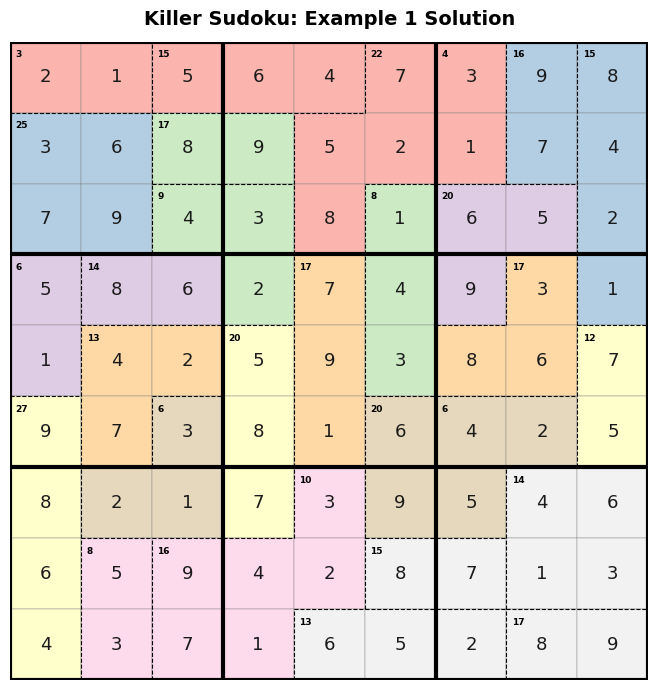

In [15]:
if solution1:
    draw_killer_sudoku(cages1, solution=solution1, title="Killer Sudoku: Example 1 Solution")

### Example 2

This puzzle is a more difficult Killer Sudoku problem as each of the cages contains more values, making the puzzle harder to solve by hand. 

In [16]:
cages2 = [
(24, [(0,0),(0,1),(1,0),(1,1)]),
(16, [(0,2),(0,3),(1,3)]),
(21, [(0,4),(1,4),(1,5),(2,5)]),
(23, [(0,5),(0,6),(0,7)]),
(15, [(0,8),(1,8),(1,7),(1,6),(2,6)]),
    
(20, [(1,2),(2,2),(2,1),(3,1),(3,2)]),

(18, [(2,0),(3,0),(4,1),(4,0),]),
(6, [(2,3),(2,4)]),
(15, [(2,7),(3,7),(4,7)]),
(24, [(2,8),(3,8),(4,8),(5,8),(5,7)]),

(19, [(3,3),(3,4),(4,3),(4,2)]),
(22, [(3,5),(3,6),(4,6)]),

(8, [(4,4),(4,5),(5,5)]),

(13, [(5,0),(6,0)]),
(19, [(5,1),(5,2),(6,1)]),
(30, [(5,3),(5,4),(6,4),(7,4)]),
(7, [(5,6),(7,6),(6,6)]),

(7, [(6,2),(6,3)]),
(9, [(6,5),(7,5)]),
(27, [(6,7),(6,8),(7,7),(8,7)]),

(20, [(7,0),(8,0),(8,1),(7,1)]),
(17, [(7,2),(7,3),(8,2),(8,3)]),
(8, [(7,8),(8,8)]),

(17, [(8,4),(8,5),(8,6)])
]

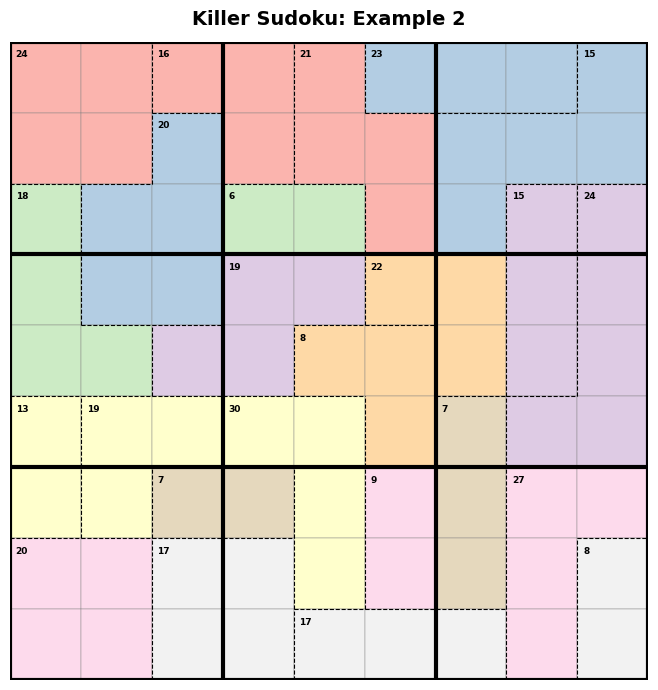

In [17]:
draw_killer_sudoku(cages2, title="Killer Sudoku: Example 2")

In [18]:
solution2 = solve_killer_sudoku(cages2)

Solver runtime: 5.011 seconds
Solution Status = Optimal

Final result:


+ ----------- + ----------- + ----------- +

|  7   2   4  |  5   3   6  |  8   9   1  |  

|  9   6   5  |  7   1   8  |  3   2   4  |  

|  3   1   8  |  4   2   9  |  5   7   6  |  

+ ----------- + ----------- + ----------- +

|  1   4   2  |  9   5   7  |  6   3   8  |  

|  6   8   3  |  2   4   1  |  9   5   7  |  

|  5   7   9  |  8   6   3  |  4   1   2  |  

+ ----------- + ----------- + ----------- +

|  8   3   6  |  1   7   5  |  2   4   9  |  

|  2   5   7  |  6   9   4  |  1   8   3  |  

|  4   9   1  |  3   8   2  |  7   6   5  |  

+ ----------- + ----------- + ----------- +

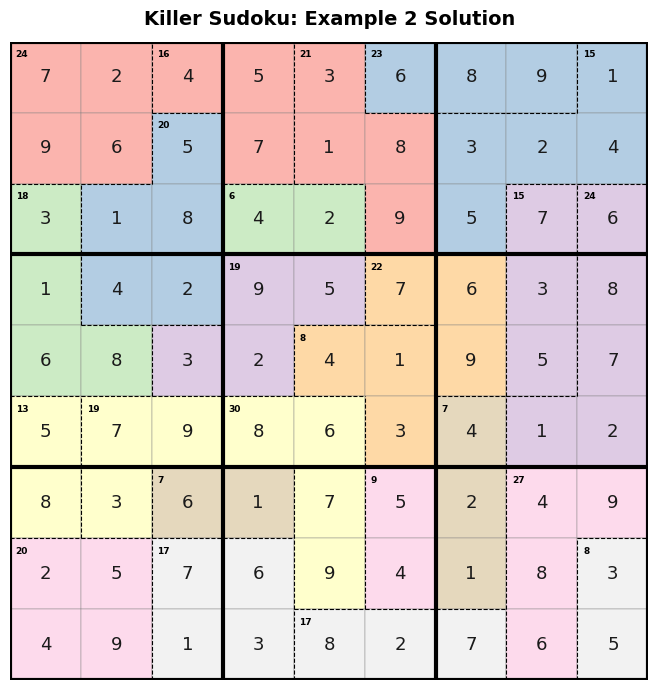

In [19]:
if solution2:
    draw_killer_sudoku(cages2, solution=solution2, title="Killer Sudoku: Example 2 Solution")

Solver runtime: 0.531 seconds
Solution Status = Optimal

Final result:


+ ----------- + ----------- + ----------- +

|  2   1   5  |  6   4   7  |  3   9   8  |  

|  3   6   8  |  9   5   2  |  1   7   4  |  

|  7   9   4  |  3   8   1  |  6   5   2  |  

+ ----------- + ----------- + ----------- +

|  5   8   6  |  2   7   4  |  9   3   1  |  

|  1   4   2  |  5   9   3  |  8   6   7  |  

|  9   7   3  |  8   1   6  |  4   2   5  |  

+ ----------- + ----------- + ----------- +

|  8   2   1  |  7   3   9  |  5   4   6  |  

|  6   5   9  |  4   2   8  |  7   1   3  |  

|  4   3   7  |  1   6   5  |  2   8   9  |  

+ ----------- + ----------- + ----------- +Solver runtime: 0.521 seconds
Solution Status = Optimal

Final result:


+ ----------- + ----------- + ----------- +

|  2   1   5  |  6   4   7  |  3   9   8  |  

|  3   6   8  |  9   5   2  |  1   7   4  |  

|  7   9   4  |  3   8   1  |  6   5   2  |  

+ ----------- + ----------- + ----------- +

|  5   8   6  |  2   7

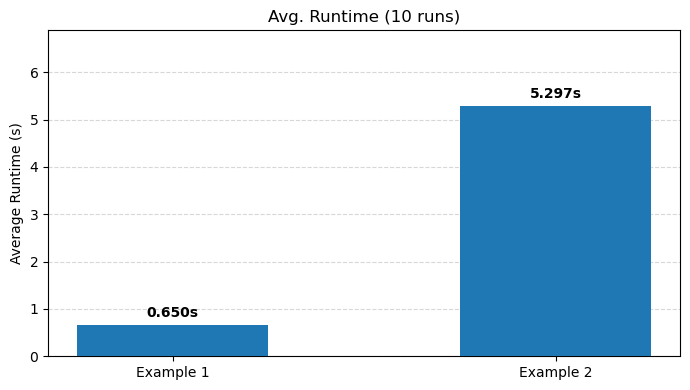

In [20]:
examples = [
    ["Example 1", cages1],
    ["Example 2", cages2]
    ]

plot_avg_runtime(examples, repeat=10)